<a href="https://colab.research.google.com/github/soheldatta17/meta_model_knee/blob/main/Meta_Model_Knee.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Mounted at /content/drive
[STEP 1/10] Downloading sub-models from Google Drive & Kaggle setup ...
  [download] Model 1 - CBAM Ensemble (TorchScript) [severity 5-class] ...


Downloading...
From (original): https://drive.google.com/uc?id=1orbyJ0UU44HT3G8inoGstlJ0DhJlQXjj
From (redirected): https://drive.google.com/uc?id=1orbyJ0UU44HT3G8inoGstlJ0DhJlQXjj&confirm=t&uuid=769dab61-4cef-4260-9433-e69eb461e617
To: /content/best_knee_ensemble_cbam.pt
100%|██████████| 168M/168M [00:03<00:00, 53.3MB/s]


  saved -> /content/best_knee_ensemble_cbam.pt  (168.2 MB)
  [download] Model 2 - Keras CNN + SE Block [JSN regression -> 2-bin] ...


Downloading...
From: https://drive.google.com/uc?id=1Hr4gHki9nl6nmXPO0xsAU7FnlfqldHZ8
To: /content/final_knee_cnn_model.keras
100%|██████████| 21.5M/21.5M [00:00<00:00, 77.0MB/s]


  saved -> /content/final_knee_cnn_model.keras  (21.5 MB)
  [download] Model 3 - MorphAttention (TorchScript) [morph 4-class -> 2] ...


Downloading...
From (original): https://drive.google.com/uc?id=16ozIZmH36J0K90bY9Jfe4YDTvS2SDDPh
From (redirected): https://drive.google.com/uc?id=16ozIZmH36J0K90bY9Jfe4YDTvS2SDDPh&confirm=t&uuid=d2654b89-4b9e-441f-a108-65692a730fc7
To: /content/final_mmorphattention.pt
100%|██████████| 189M/189M [00:04<00:00, 39.3MB/s]


  saved -> /content/final_mmorphattention.pt  (189.1 MB)

[STEP 1/10] Configuring Kaggle ...

[STEP 1/10] Downloading: hafiznouman786/annotated-dataset-for-knee-arthritis-detection ...
  Root 'Training' -> 1633 images ingested.

[STEP 1/10] Downloading: shashwatwork/knee-osteoarthritis-dataset-with-severity ...
  Root 'train' -> 5778 images ingested.

[STEP 1/10] Downloading: tommyngx/kneeoa ...
  Root 'train' -> 0 images ingested.
  Root '.' -> 0 images ingested.

[STEP 1/10] Pool: 7411 unique images
  Grade dist: {0: 2799, 1: 1520, 2: 1743, 3: 970, 4: 379}

[STEP 2/10] Importing libraries ...
[STEP 2/10] Device: cuda

[STEP 3/10] Loading sub-models ...
[STEP 3/10] Model 1 loaded  (severity | TorchScript)
[STEP 3/10] Model 2 loaded  (JSN | Keras | last act='softmax')
[STEP 3/10] Model 3 loaded  (morphology | TorchScript)
[STEP 3/10] All sub-models ready.

[STEP 4/10] Configuration ...
  Vfusion (raw)     : 11D  [sev(5) | jsn(2) | morph(4)]
  Fine-tuned head   : M1 backbone -> 512D -> 

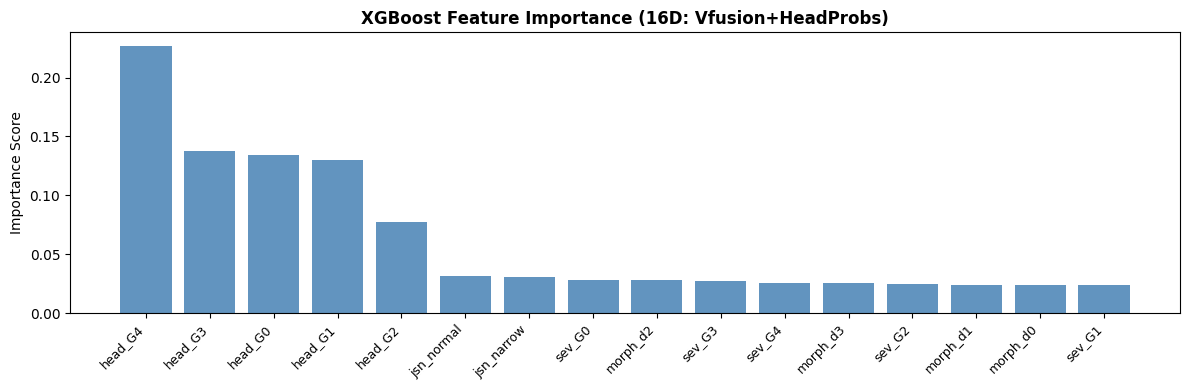

  Saved xgb_feature_importance.png


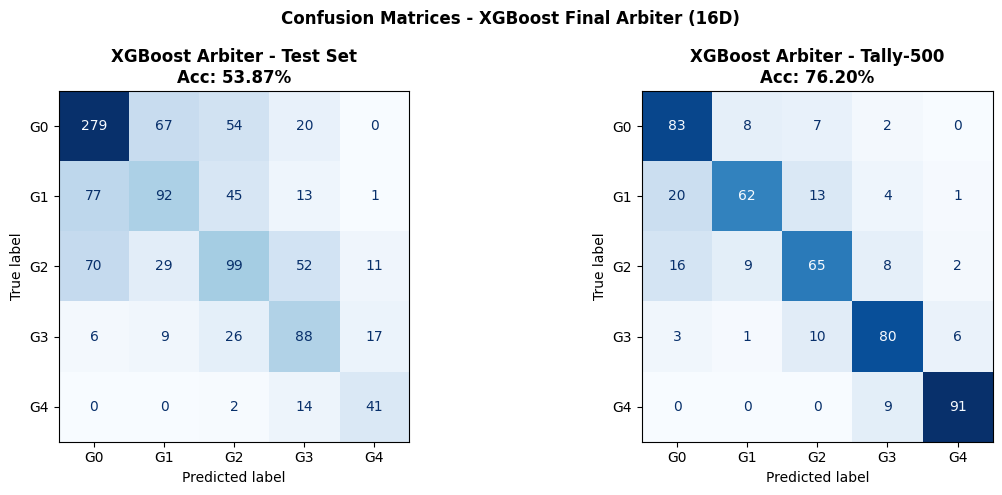

  Saved confusion_matrices_xgb.png
  Saved classification_report_xgb.txt

  [Test Set Report]
              precision    recall  f1-score   support

  Gr0 Normal       0.65      0.66      0.65       420
Gr1 Doubtful       0.47      0.40      0.43       228
    Gr2 Mild       0.44      0.38      0.41       261
Gr3 Moderate       0.47      0.60      0.53       146
  Gr4 Severe       0.59      0.72      0.65        57

    accuracy                           0.54      1112
   macro avg       0.52      0.55      0.53      1112
weighted avg       0.53      0.54      0.53      1112


----------------------------------------------------------------------
  GRAD-CAM - Explainability on Model 1 (EfficientNet-B5 + CBAM)
  Target: predicted KL severity class
----------------------------------------------------------------------

  Generating Grad-CAM dashboards for 5 random tally samples ...


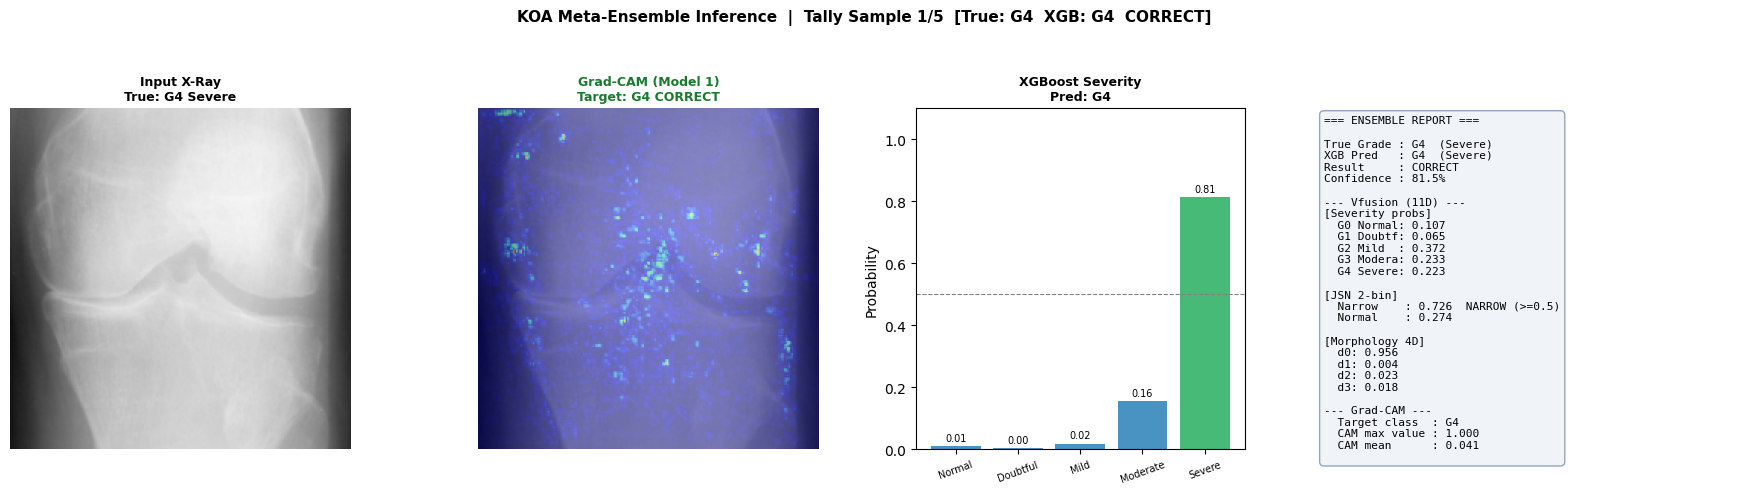

  Dashboard 1/5 saved -> ./meta_model_outputs_v3/dashboard_gradcam_1.png


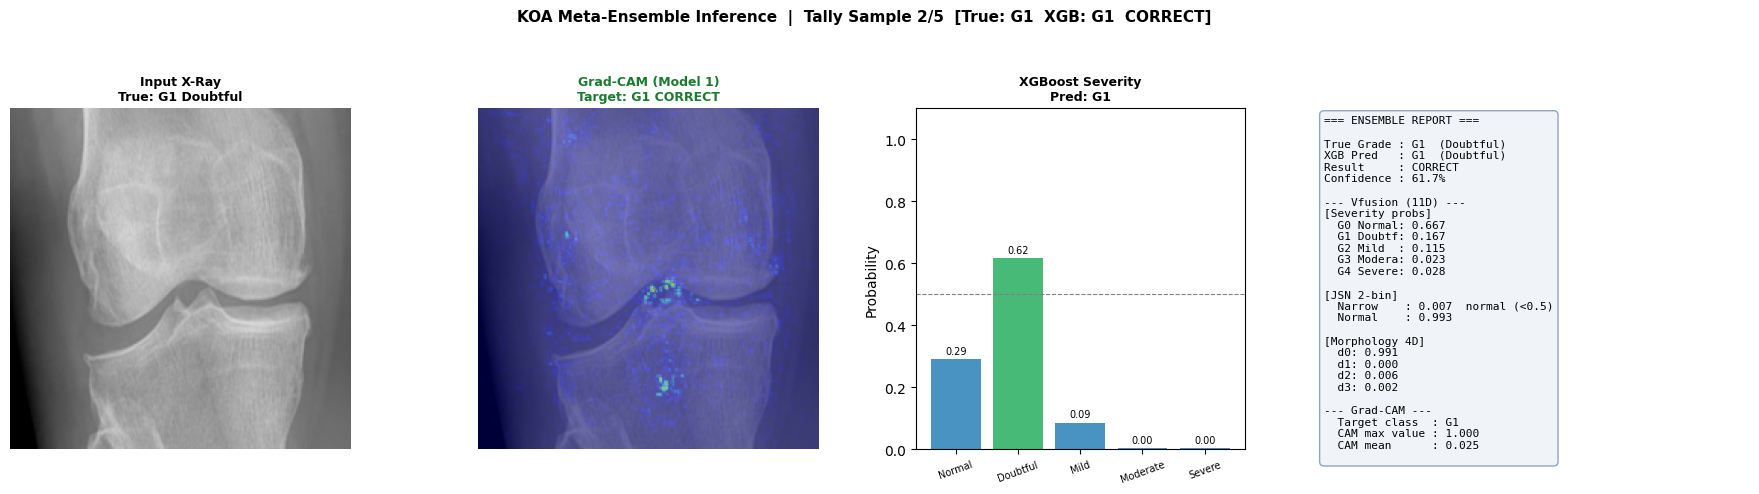

  Dashboard 2/5 saved -> ./meta_model_outputs_v3/dashboard_gradcam_2.png


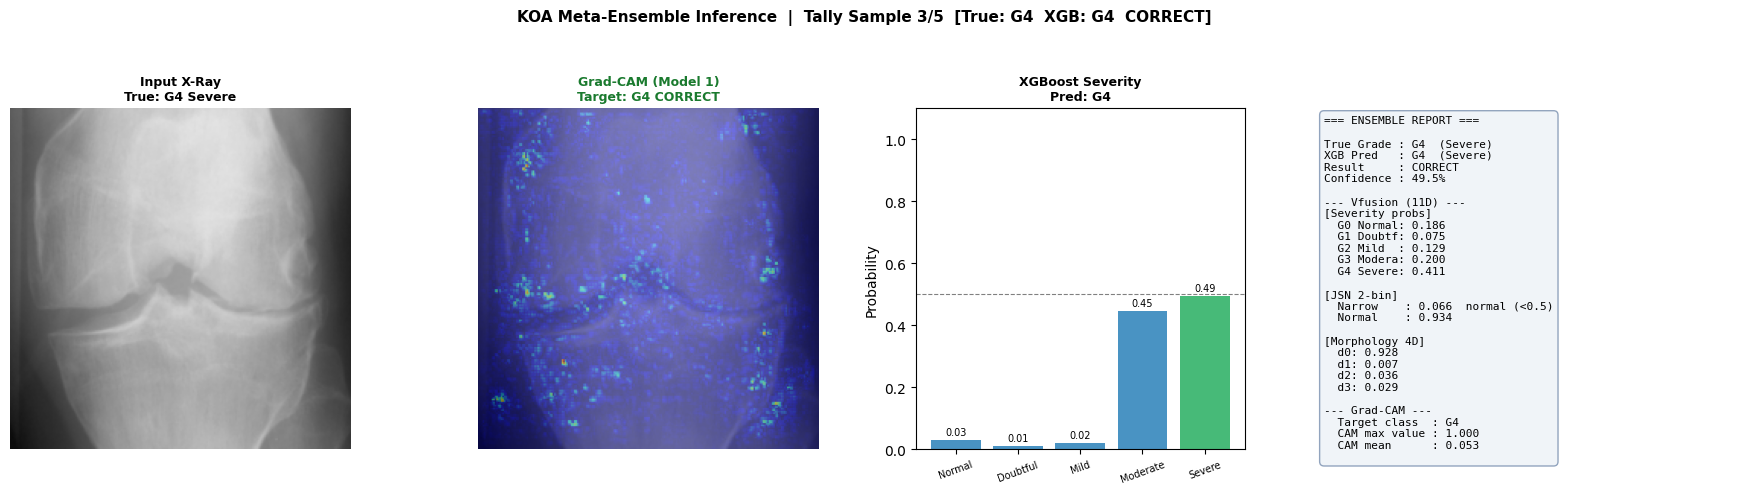

  Dashboard 3/5 saved -> ./meta_model_outputs_v3/dashboard_gradcam_3.png


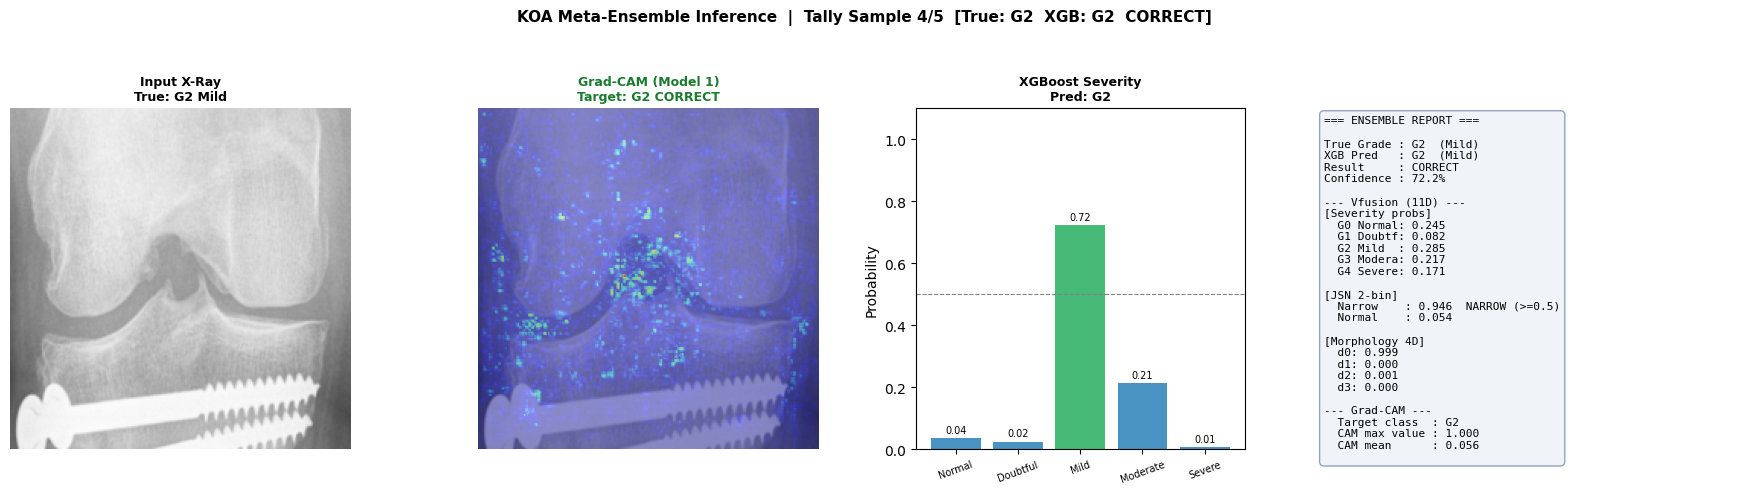

  Dashboard 4/5 saved -> ./meta_model_outputs_v3/dashboard_gradcam_4.png


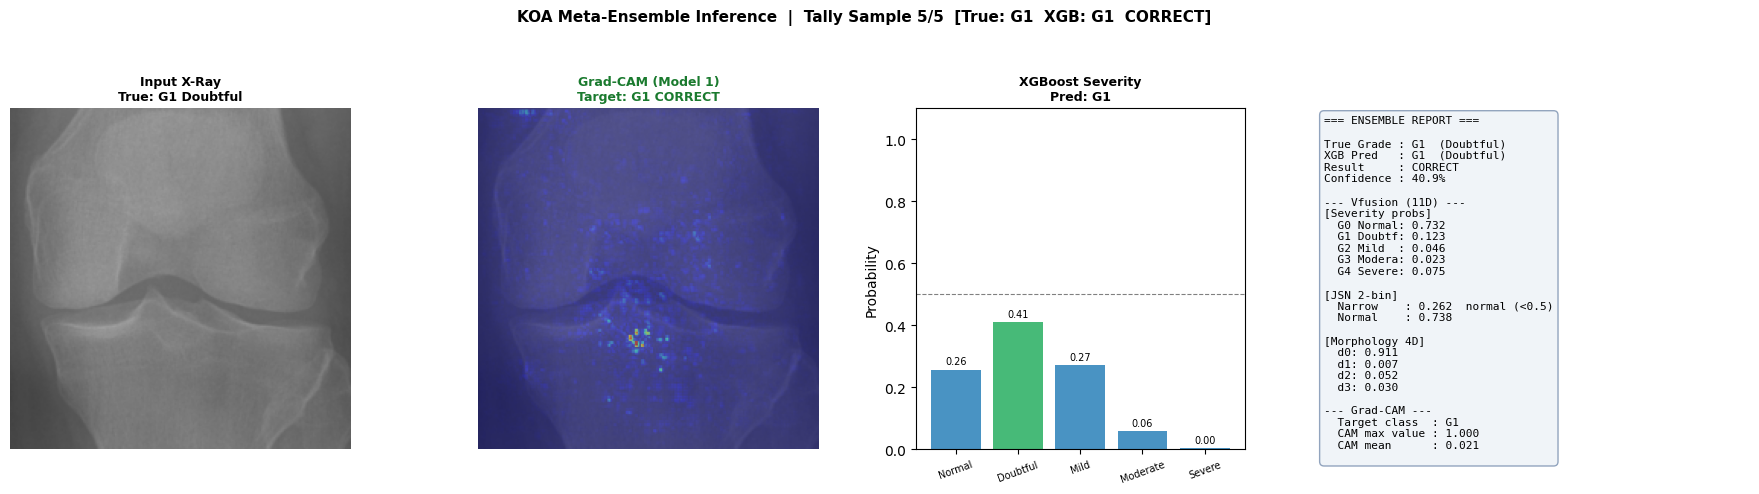

  Dashboard 5/5 saved -> ./meta_model_outputs_v3/dashboard_gradcam_5.png

[DONE] FINAL RESULTS

  Architecture:
    Sub-models     : 3  (M1=severity, M2=JSN->2bin, M3=morphology)
    M1 backbone    : EfficientNet-B5 + ResNet50 + CBAM -> 512D embedding
    KL-grade head  : 512D -> 256D -> 5 classes (fine-tuned)
    Vfusion        : 11D  (sev5 + jsn2 + morph4)
    XGBoost input  : 16D  (Vfusion + head probs)
    Final arbiter  : XGBoost (train+val fit, early stop on test)

  Performance:
    KL-head alone  — Test Acc : 52.25%
    XGBoost Ensemble:
      Val Acc       : 60.87%
      Val Bal Acc   : 64.70%
      Test Acc      : 53.87%
      Test Bal Acc  : 55.38%
      Tally Acc     : 76.20%

  Saved outputs:
    classification_report_xgb.txt                 0.00 MB
    confusion_matrices_xgb.png                    0.07 MB
    dashboard_gradcam_1.png                       0.41 MB
    dashboard_gradcam_2.png                       0.41 MB
    dashboard_gradcam_3.png                       0.4

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import subprocess
import sys

try:
    import gdown
except ImportError:
    print("[SETUP] Installing gdown ...")
    subprocess.run([sys.executable, "-m", "pip", "install", "gdown", "-q"], check=True)
    import gdown

print("=" * 70)
print("[STEP 1/10] Downloading sub-models from Google Drive & Kaggle setup ...")
print("=" * 70)

import os
import zipfile
import shutil
import hashlib

DRIVE_ASSETS = {
    "model1": {
        "id"   : "1orbyJ0UU44HT3G8inoGstlJ0DhJlQXjj",
        "local": "/content/best_knee_ensemble_cbam.pt",
        "desc" : "Model 1 - CBAM Ensemble (TorchScript) [severity 5-class]",
    },
    "model2": {
        "id"   : "1Hr4gHki9nl6nmXPO0xsAU7FnlfqldHZ8",
        "local": "/content/final_knee_cnn_model.keras",
        "desc" : "Model 2 - Keras CNN + SE Block [JSN regression -> 2-bin]",
    },
    "model3": {
        "id"   : "16ozIZmH36J0K90bY9Jfe4YDTvS2SDDPh",
        "local": "/content/final_mmorphattention.pt",
        "desc" : "Model 3 - MorphAttention (TorchScript) [morph 4-class -> 2]",
    },
}

MODEL1_PATH = DRIVE_ASSETS["model1"]["local"]
MODEL2_PATH = DRIVE_ASSETS["model2"]["local"]
MODEL3_PATH = DRIVE_ASSETS["model3"]["local"]


def _gdrive_download(key: str) -> str:
    asset = DRIVE_ASSETS[key]
    local = asset["local"]
    if os.path.exists(local):
        mb = os.path.getsize(local) / 1e6
        print(f"  [cached] {asset['desc']}  ({mb:.1f} MB)")
        return local
    print(f"  [download] {asset['desc']} ...")
    gdown.download(f"https://drive.google.com/uc?id={asset['id']}", local, quiet=False)
    if not os.path.exists(local):
        raise RuntimeError(f"FATAL: Download failed for {asset['desc']}. "
                           f"Check Drive share settings. ID={asset['id']}")
    print(f"  saved -> {local}  ({os.path.getsize(local)/1e6:.1f} MB)")
    return local


for k in ["model1", "model2", "model3"]:
    _gdrive_download(k)

print("\n[STEP 1/10] Configuring Kaggle ...")
os.makedirs(os.path.expanduser("~/.kaggle"), exist_ok=True)
subprocess.run(["cp", "/content/kaggle.json", os.path.expanduser("~/.kaggle/")], check=True)
subprocess.run(["chmod", "600", os.path.expanduser("~/.kaggle/kaggle.json")], check=True)

DOWNLOAD_DIR = "/content"
POOL_DIR     = "./knee_pool"
os.makedirs(POOL_DIR, exist_ok=True)

KAGGLE_DATASETS = [
    {
        "slug"    : "hafiznouman786/annotated-dataset-for-knee-arthritis-detection",
        "zip_stem": "annotated-dataset-for-knee-arthritis-detection",
        "roots"   : ["Training", "training", "train", "."],
    },
    {
        "slug"    : "shashwatwork/knee-osteoarthritis-dataset-with-severity",
        "zip_stem": "knee-osteoarthritis-dataset-with-severity",
        "roots"   : ["train", "Train", "training", "."],
    },
    {
        "slug"    : "tommyngx/kneeoa",
        "zip_stem": "kneeoa",
        "roots"   : ["train", "Train", "."],
    },
]

seen_hashes   = set()
pool_manifest = []


def _sha256_prefix(path: str, nbytes: int = 8192) -> str:
    h = hashlib.sha256()
    with open(path, "rb") as f:
        h.update(f.read(nbytes))
    return h.hexdigest()


def _grade_from_folder(name: str):
    import re
    m = re.match(r'^(\d+)', name.strip())
    if m and int(m.group(1)) <= 4:
        return int(m.group(1))
    grade_map = {"normal": 0, "doubtful": 1, "mild": 2, "moderate": 3, "severe": 4}
    for k, v in grade_map.items():
        if k in name.lower():
            return v
    return None


def _ingest_root(root_dir: str, tag: str) -> int:
    added = 0
    for folder in sorted(os.listdir(root_dir)):
        class_dir = os.path.join(root_dir, folder)
        if not os.path.isdir(class_dir):
            continue
        grade = _grade_from_folder(folder)
        if grade is None:
            continue
        grade_pool = os.path.join(POOL_DIR, str(grade))
        os.makedirs(grade_pool, exist_ok=True)
        for fname in os.listdir(class_dir):
            if not fname.lower().endswith((".png", ".jpg", ".jpeg")):
                continue
            src = os.path.join(class_dir, fname)
            h   = _sha256_prefix(src)
            if h in seen_hashes:
                continue
            seen_hashes.add(h)
            dst = os.path.join(grade_pool, f"{tag}_{fname}")
            shutil.copy2(src, dst)
            pool_manifest.append((dst, grade))
            added += 1
    return added


for ds in KAGGLE_DATASETS:
    slug, zip_stem, roots = ds["slug"], ds["zip_stem"], ds["roots"]
    zip_path = os.path.join(DOWNLOAD_DIR, f"{zip_stem}.zip")
    tag      = slug.split("/")[-1][:12]
    print(f"\n[STEP 1/10] Downloading: {slug} ...")
    try:
        subprocess.run(
            ["kaggle", "datasets", "download", "-d", slug, "-p", DOWNLOAD_DIR],
            check=True
        )
        with zipfile.ZipFile(zip_path, "r") as zf:
            zf.extractall(DOWNLOAD_DIR)
    except Exception as ex:
        print(f"  WARNING: {ex}")
        continue
    for root_cand in roots:
        rp = os.path.join(DOWNLOAD_DIR, root_cand)
        if os.path.isdir(rp):
            n = _ingest_root(rp, tag)
            print(f"  Root '{root_cand}' -> {n} images ingested.")
            if n > 0:
                break

from collections import Counter as _Counter
print(f"\n[STEP 1/10] Pool: {len(pool_manifest)} unique images")
print(f"  Grade dist: {dict(sorted(_Counter(g for _, g in pool_manifest).items()))}")
if not pool_manifest:
    raise RuntimeError("FATAL: No images. Check Kaggle credentials/slugs.")


print("\n" + "=" * 70)
print("[STEP 2/10] Importing libraries ...")
print("=" * 70)

import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.cm as cm
import random
import copy
import pickle
import warnings
warnings.filterwarnings("ignore")
from collections import Counter

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
import cv2
import tensorflow as tf

from sklearn.model_selection import train_test_split, RandomizedSearchCV, StratifiedKFold
from sklearn.metrics import (confusion_matrix, ConfusionMatrixDisplay,
                             classification_report, accuracy_score, balanced_accuracy_score)
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import mutual_info_classif

try:
    from xgboost import XGBClassifier
except ImportError:
    subprocess.run(["pip", "install", "xgboost", "-q"], check=True)
    from xgboost import XGBClassifier

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"[STEP 2/10] Device: {DEVICE}")


print("\n" + "=" * 70)
print("[STEP 3/10] Loading sub-models ...")
print("=" * 70)

model1 = torch.jit.load(MODEL1_PATH, map_location=DEVICE)
model1.eval()
print("[STEP 3/10] Model 1 loaded  (severity | TorchScript)")

model2_tf = tf.keras.models.load_model(MODEL2_PATH)
model2_tf.trainable = False
_m2_last_act = None
try:
    _m2_last_act = model2_tf.layers[-1].activation.__name__
except Exception:
    pass
MODEL2_HAS_SOFTMAX = (_m2_last_act == "softmax")
print(f"[STEP 3/10] Model 2 loaded  (JSN | Keras | last act='{_m2_last_act}')")

model3 = torch.jit.load(MODEL3_PATH, map_location=DEVICE)
model3.eval()
print("[STEP 3/10] Model 3 loaded  (morphology | TorchScript)")
print("[STEP 3/10] All sub-models ready.\n")


print("=" * 70)
print("[STEP 4/10] Configuration ...")
print("=" * 70)

SEVERITY_NAMES = ["Normal", "Doubtful", "Mild", "Moderate", "Severe"]
NUM_SEVERITY   = 5
NUM_JSN        = 2
NUM_MORPH      = 4
FUSION_DIM     = NUM_SEVERITY + NUM_JSN + NUM_MORPH   # 11D raw

HEAD_HIDDEN    = 256
HEAD_EPOCHS    = 40
HEAD_LR        = 3e-4
HEAD_BATCH     = 64
HEAD_PATIENCE  = 8

TALLY_N  = 500
SAVE_DIR = "./meta_model_outputs_v3"
os.makedirs(SAVE_DIR, exist_ok=True)

print(f"  Vfusion (raw)     : {FUSION_DIM}D  [sev(5) | jsn(2) | morph(4)]")
print(f"  Fine-tuned head   : M1 backbone -> 512D -> KL-grade head (new)")
print(f"  Final arbiter     : XGBoost on [Vfusion(11D) + head_probs(5D)] = 16D")
print(f"  Outputs           : {SAVE_DIR}")


print("\n" + "=" * 70)
print("[STEP 5/10] Preprocessing helpers ...")
print("=" * 70)

transform_pt = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])


def preprocess_for_pt(image_path: str) -> torch.Tensor:
    img = Image.open(image_path).convert("RGB")
    return transform_pt(img).unsqueeze(0).to(DEVICE)


def preprocess_for_tf(image_path: str):
    img = tf.io.read_file(image_path)
    img = tf.image.decode_image(img, channels=1, expand_animations=False)
    img = tf.image.resize(img, [256, 256])
    img = tf.cast(img, tf.float32)
    return tf.expand_dims(img, axis=0)


def jsn_to_2bin(raw_output) -> np.ndarray:
    if MODEL2_HAS_SOFTMAX:
        probs5 = np.array(raw_output[0], dtype=np.float32)
    else:
        probs5 = tf.nn.softmax(raw_output).numpy()[0].astype(np.float32)
    p_narrow = float(probs5[2] + probs5[3] + probs5[4])
    p_normal = float(probs5[0] + probs5[1])
    return np.array([p_narrow, p_normal], dtype=np.float32)


print("[STEP 5/10] Preprocessing helpers defined.")
print("  JSN 2-bin: P(narrow)=sum(prob[grade>=2]), P(normal)=sum(prob[grade<2])")


print("\n" + "=" * 70)
print("[STEP 6/10] Model 3 preprocessing — raw [0,255] + M1 backbone extractor ...")
print("=" * 70)

transform_morph = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
])

def preprocess_morph(image_path: str) -> torch.Tensor:
    img = Image.open(image_path).convert("RGB")
    tensor = transform_morph(img) * 255.0
    return tensor.unsqueeze(0).to(DEVICE)

print("  Model 3: raw [0,255] input, softmax, all 4 dims.")


def extract_m1_backbone(image_path: str) -> torch.Tensor:
    img_pt = preprocess_for_pt(image_path)
    with torch.no_grad():
        eff_feat = model1.effnet.features(img_pt)
        eff_feat = model1.eff_attention(eff_feat)
        eff_feat = model1.effnet.avgpool(eff_feat)
        x1 = torch.flatten(eff_feat, 1)

        r = model1.resnet.conv1(img_pt)
        r = model1.resnet.bn1(r); r = model1.resnet.relu(r); r = model1.resnet.maxpool(r)
        r = model1.resnet.layer1(r); r = model1.resnet.layer2(r)
        r = model1.resnet.layer3(r); r = model1.resnet.layer4(r)
        r = model1.res_attention(r); r = model1.resnet.avgpool(r)
        x2 = torch.flatten(r, 1)

        concat = torch.cat([x1, x2], dim=1)   # (1, 2560)
        clf_children = list(model1.classifier.named_children())
        h = concat
        for name, layer in clf_children[:-1]:  # stop before final Linear(512->5)
            h = layer(h)
        return h   # (1, 512) — trained representation


print("  M1 backbone extractor: 2560D concat -> 512D pre-logit embedding.")
print("  This is the trained EfficientNet-B5 + ResNet50 + CBAM feature vector.")


print("\n" + "=" * 70)
print("[STEP 7/10] Feature extraction — Vfusion 11D + backbone 512D ...")
print("=" * 70)


def extract_features(image_path: str) -> tuple:
    img_pt = preprocess_for_pt(image_path)

    with torch.no_grad():
        sev_probs = F.softmax(model1(img_pt), dim=1).cpu().numpy()[0]

    img_tf   = preprocess_for_tf(image_path)
    raw_m2   = model2_tf.predict(img_tf, verbose=0)
    jsn_bins = jsn_to_2bin(raw_m2)

    img_pt_m3 = preprocess_morph(image_path)
    with torch.no_grad():
        morph4 = F.softmax(model3(img_pt_m3), dim=1).cpu().numpy()[0].astype(np.float32)

    vfusion = np.concatenate([sev_probs, jsn_bins, morph4])   # 11D

    backbone = extract_m1_backbone(image_path).cpu().numpy()[0]  # 512D

    return vfusion, backbone


print("[STEP 7/10] extract_features() -> (11D vfusion, 512D backbone).")


print("\n" + "=" * 70)
print("[STEP 8/10] Building feature dataset ...")
print("=" * 70)

all_paths  = [p for p, _ in pool_manifest]
raw_labels = [g for _, g in pool_manifest]

CLASS_IDS  = sorted(set(raw_labels))
grade2idx  = {g: i for i, g in enumerate(CLASS_IDS)}
all_labels = [grade2idx[g] for g in raw_labels]
NUM_CLS    = len(CLASS_IDS)

print(f"  Pool: {len(all_paths)} images | Classes: {CLASS_IDS}")

tally_paths, tally_labels = [], []
per_cls = max(1, TALLY_N // NUM_CLS)
for cid in CLASS_IDS:
    pool_idx = [i for i, l in enumerate(all_labels) if l == grade2idx[cid]]
    chosen   = random.sample(pool_idx, min(per_cls, len(pool_idx)))
    tally_paths  += [all_paths[i]  for i in chosen]
    tally_labels += [all_labels[i] for i in chosen]
actual_tally = len(tally_paths)
print(f"  Tally: {actual_tally} images | dist: {dict(sorted(Counter(tally_labels).items()))}")

print(f"\n  Extracting (Vfusion 11D + backbone 512D) for ALL {len(all_paths)} images ...")
all_vfusion:  list = []
all_backbone: list = []
for i, path in enumerate(all_paths, 1):
    try:
        vf, bb = extract_features(path)
    except Exception as ex:
        print(f"    WARN [{i}] {path}: {ex} - zeros used.")
        vf = np.zeros(FUSION_DIM, dtype=np.float32)
        bb = np.zeros(512, dtype=np.float32)
    all_vfusion.append(vf)
    all_backbone.append(bb)
    if i % 200 == 0 or i == len(all_paths):
        print(f"    {i}/{len(all_paths)} ...")

all_vfusion  = np.array(all_vfusion,  dtype=np.float32)
all_backbone = np.array(all_backbone, dtype=np.float32)
print(f"  Vfusion matrix : {all_vfusion.shape}")
print(f"  Backbone matrix: {all_backbone.shape}")

path2idx  = {p: i for i, p in enumerate(all_paths)}
tally_idx = [path2idx[p] for p in tally_paths]

X_tally    = all_vfusion[tally_idx]
Bb_tally   = all_backbone[tally_idx]
y_tally    = np.array(tally_labels)

X_tv, X_test, Bb_tv, Bb_test, y_tv, y_test = train_test_split(
    all_vfusion, all_backbone, all_labels,
    test_size=0.15, stratify=all_labels, random_state=42)
X_train, X_val, Bb_train, Bb_val, y_train, y_val = train_test_split(
    X_tv, Bb_tv, y_tv,
    test_size=0.176, stratify=y_tv, random_state=42)

y_train_np = np.array(y_train)
y_val_np   = np.array(y_val)
y_test_np  = np.array(y_test)

print(f"\n  Split -> Train: {len(X_train)} | Val: {len(X_val)} | Test: {len(X_test)}")
print(f"  Train dist: {dict(sorted(Counter(y_train).items()))}")

FEAT_NAMES = (
    [f"sev_G{i}" for i in range(5)] +
    ["jsn_narrow", "jsn_normal"] +
    ["morph_d0", "morph_d1", "morph_d2", "morph_d3"]
)


print("\n" + "=" * 70)
print("[STEP 9/10] Fine-tuned KL-grade head on M1 backbone (512D -> 5 classes) ...")
print("=" * 70)


class BackboneDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.long)
    def __len__(self): return len(self.y)
    def __getitem__(self, i): return self.X[i], self.y[i]


cnt_s    = Counter(y_train)
cls_wts  = [len(y_train) / (NUM_CLS * cnt_s.get(i, 1)) for i in range(NUM_CLS)]
cls_tensor = torch.FloatTensor(cls_wts).to(DEVICE)
print(f"  Class weights: {[round(w,3) for w in cls_wts]}")

train_ds_bb = BackboneDataset(Bb_train, y_train)
val_ds_bb   = BackboneDataset(Bb_val,   y_val)
train_ld_bb = DataLoader(train_ds_bb, batch_size=HEAD_BATCH, shuffle=True,  drop_last=True)
val_ld_bb   = DataLoader(val_ds_bb,   batch_size=HEAD_BATCH, shuffle=False)


class KLGradeHead(nn.Module):
    def __init__(self, in_dim=512, hidden=HEAD_HIDDEN, num_cls=5):
        super().__init__()
        self.net = nn.Sequential(
            nn.BatchNorm1d(in_dim),
            nn.Dropout(0.4),
            nn.Linear(in_dim, hidden),
            nn.ReLU(),
            nn.BatchNorm1d(hidden),
            nn.Dropout(0.3),
            nn.Linear(hidden, hidden // 2),
            nn.ReLU(),
            nn.Linear(hidden // 2, num_cls),
        )
    def forward(self, x): return self.net(x)


head = KLGradeHead(in_dim=512, hidden=HEAD_HIDDEN, num_cls=NUM_CLS).to(DEVICE)
criterion_head = nn.CrossEntropyLoss(weight=cls_tensor, label_smoothing=0.05)
opt_head = optim.AdamW(head.parameters(), lr=HEAD_LR, weight_decay=1e-4)
sched_head = optim.lr_scheduler.CosineAnnealingLR(opt_head, T_max=HEAD_EPOCHS, eta_min=1e-6)

best_head_wts  = copy.deepcopy(head.state_dict())
best_head_vacc = 0.0
no_improve_h   = 0

print(f"  Training KL-grade head for up to {HEAD_EPOCHS} epochs (patience={HEAD_PATIENCE}) ...")
for epoch in range(HEAD_EPOCHS):
    head.train()
    tr_c = tr_t = 0
    for Xb, yb in train_ld_bb:
        Xb, yb = Xb.to(DEVICE), yb.to(DEVICE)
        opt_head.zero_grad()
        loss = criterion_head(head(Xb), yb)
        loss.backward()
        opt_head.step()
        tr_c += (head(Xb).argmax(1) == yb).sum().item()
        tr_t += yb.size(0)
    sched_head.step()

    head.eval()
    va_c = va_t = 0
    with torch.no_grad():
        for Xb, yb in val_ld_bb:
            Xb, yb = Xb.to(DEVICE), yb.to(DEVICE)
            va_c += (head(Xb).argmax(1) == yb).sum().item()
            va_t += yb.size(0)
    tr_a = tr_c / tr_t;  va_a = va_c / va_t
    print(f"  E{epoch+1:02d}/{HEAD_EPOCHS} | tr={tr_a:.4f}  va={va_a:.4f}", end="")
    if va_a > best_head_vacc:
        best_head_vacc = va_a
        best_head_wts  = copy.deepcopy(head.state_dict())
        no_improve_h   = 0
        print("  *", end="")
    else:
        no_improve_h += 1
    print()
    if no_improve_h >= HEAD_PATIENCE:
        print(f"  Early stop at epoch {epoch+1}.")
        break

head.load_state_dict(best_head_wts)
print(f"  Best head val acc: {best_head_vacc*100:.2f}%")
torch.save(head.state_dict(), os.path.join(SAVE_DIR, "kl_grade_head.pth"))


def get_head_probs(Bb: np.ndarray) -> np.ndarray:
    head.eval()
    ds  = BackboneDataset(Bb, np.zeros(len(Bb), dtype=int))
    ld  = DataLoader(ds, batch_size=HEAD_BATCH)
    out = []
    with torch.no_grad():
        for Xb, _ in ld:
            out.append(F.softmax(head(Xb.to(DEVICE)), dim=1).cpu().numpy())
    return np.vstack(out)


Hp_train  = get_head_probs(Bb_train)
Hp_val    = get_head_probs(Bb_val)
Hp_test   = get_head_probs(Bb_test)
Hp_tally  = get_head_probs(Bb_tally)
print(f"  Head probs shape: train={Hp_train.shape}  val={Hp_val.shape}")

head_val_acc  = accuracy_score(y_val_np,  Hp_val.argmax(1))
head_test_acc = accuracy_score(y_test_np, Hp_test.argmax(1))
print(f"  Head alone — Val: {head_val_acc*100:.2f}%  Test: {head_test_acc*100:.2f}%")


print("\n" + "=" * 70)
print("[STEP 10/10] XGBoost on [Vfusion(11D) + HeadProbs(5D)] = 16D ...")
print("=" * 70)

def build_xgb_input(X_vf, Hp):
    return np.hstack([X_vf, Hp])   # 11 + 5 = 16D

Xf_train = build_xgb_input(X_train, Hp_train)
Xf_val   = build_xgb_input(X_val,   Hp_val)
Xf_test  = build_xgb_input(X_test,  Hp_test)
Xf_tally = build_xgb_input(X_tally, Hp_tally)

FEAT_NAMES_XGB = FEAT_NAMES + [f"head_G{i}" for i in range(NUM_CLS)]

scaler   = StandardScaler()
Xb_train = scaler.fit_transform(Xf_train)
Xb_val   = scaler.transform(Xf_val)
Xb_test  = scaler.transform(Xf_test)
Xb_tally = scaler.transform(Xf_tally)

print(f"  XGBoost input shape: {Xb_train.shape}")

feat_mi = mutual_info_classif(Xb_train, y_train_np, random_state=42)
print(f"  {'Feature':<14} {'MI':>8}")
for n, m in zip(FEAT_NAMES_XGB, feat_mi):
    print(f"  {n:<14}  MI={m:.4f}")

sample_weight = np.array([len(y_train) / (NUM_CLS * cnt_s.get(y, 1)) for y in y_train])

param_dist = {
    "max_depth"        : [3, 4, 5, 6],
    "learning_rate"    : [0.01, 0.02, 0.03, 0.05],
    "n_estimators"     : [500, 800, 1000, 1500, 2000],
    "subsample"        : [0.7, 0.8, 0.9, 1.0],
    "colsample_bytree" : [0.7, 0.8, 0.9, 1.0],
    "min_child_weight" : [1, 2, 3],
    "gamma"            : [0, 0.05, 0.1],
    "reg_alpha"        : [0, 0.01, 0.05],
    "reg_lambda"       : [1.0, 1.5, 2.0],
}

base_xgb = XGBClassifier(
    objective    = "multi:softprob",
    num_class    = NUM_CLS,
    eval_metric  = "mlogloss",
    tree_method  = "hist",
    device       = "cuda" if torch.cuda.is_available() else "cpu",
    random_state = 42,
    verbosity    = 0,
)

search = RandomizedSearchCV(
    base_xgb, param_dist,
    n_iter       = 60,
    scoring      = "accuracy",
    cv           = StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    random_state = 42,
    n_jobs       = 1,
    verbose      = 1,
)
search.fit(Xb_train, y_train_np, sample_weight=sample_weight)
print(f"\n  Best CV accuracy: {search.best_score_*100:.2f}%")
print(f"  Best params: {search.best_params_}")

best_p = dict(search.best_params_)
best_p.update(dict(
    objective             = "multi:softprob",
    num_class             = NUM_CLS,
    eval_metric           = "mlogloss",
    tree_method           = "hist",
    device                = "cuda" if torch.cuda.is_available() else "cpu",
    random_state          = 42,
    verbosity             = 0,
    early_stopping_rounds = 50,
))

Xb_tv   = scaler.transform(build_xgb_input(
    np.vstack([X_train, X_val]),
    np.vstack([Hp_train, Hp_val])))
y_tv_np = np.concatenate([y_train_np, y_val_np])
sw_val  = np.array([len(y_val) / (NUM_CLS * cnt_s.get(y, 1)) for y in y_val])
sw_tv   = np.concatenate([sample_weight, sw_val])

xgb = XGBClassifier(**best_p)
xgb.fit(Xb_tv, y_tv_np,
        sample_weight=sw_tv,
        eval_set=[(Xb_test, y_test_np)],
        verbose=100)

val_acc      = accuracy_score(y_val_np,  xgb.predict(Xb_val))
test_acc     = accuracy_score(y_test_np, xgb.predict(Xb_test))
val_bal_acc  = balanced_accuracy_score(y_val_np,  xgb.predict(Xb_val))
test_bal_acc = balanced_accuracy_score(y_test_np, xgb.predict(Xb_test))

print(f"\n  Head alone  — Test Acc: {head_test_acc*100:.2f}%")
print(f"  XGBoost Val Acc       : {val_acc*100:.2f}%")
print(f"  XGBoost Val Bal Acc   : {val_bal_acc*100:.2f}%")
print(f"  XGBoost Test Acc      : {test_acc*100:.2f}%")
print(f"  XGBoost Test Bal Acc  : {test_bal_acc*100:.2f}%")

print("\n  Saving all model artifacts ...")
torch.save(head.state_dict(), os.path.join(SAVE_DIR, "kl_grade_head.pth"))
print(f"  KL-grade head -> {os.path.join(SAVE_DIR, 'kl_grade_head.pth')}")

xgb_pkl = os.path.join(SAVE_DIR, "xgboost_arbiter.pkl")
with open(xgb_pkl, "wb") as f:
    pickle.dump({"xgb": xgb, "scaler": scaler}, f)
print(f"  XGBoost + scaler -> {xgb_pkl}")

pipeline_bundle = {
    "xgb"              : xgb,
    "scaler"           : scaler,
    "head_state_dict"  : head.state_dict(),
    "head_config"      : {"in_dim": 512, "hidden": HEAD_HIDDEN, "num_cls": NUM_CLS},
    "fusion_dim"       : FUSION_DIM,
    "feature_names"    : FEAT_NAMES_XGB,
    "class_ids"        : CLASS_IDS,
    "grade2idx"        : grade2idx,
    "severity_names"   : SEVERITY_NAMES,
    "num_classes"      : NUM_CLS,
    "version"          : "v4.0",
    "description"      : "KOA: Vfusion(11D)+HeadProbs(5D)=16D -> XGBoost -> KL Grade",
}
bundle_path = os.path.join(SAVE_DIR, "full_pipeline_bundle.pkl")
with open(bundle_path, "wb") as f:
    pickle.dump(pipeline_bundle, f)
print(f"  Full pipeline bundle -> {bundle_path}")
print("\n  All artifacts saved.\n")


print("\n" + "=" * 70)
print("[EVAL] Evaluation + Grad-CAM + Dashboard ...")
print("=" * 70)

importances = xgb.feature_importances_
idx_sorted  = np.argsort(importances)[::-1]

fig, ax = plt.subplots(figsize=(12, 4))
ax.bar(range(len(importances)), importances[idx_sorted], color="steelblue", alpha=0.85)
ax.set_xticks(range(len(importances)))
ax.set_xticklabels([FEAT_NAMES_XGB[i] for i in idx_sorted], rotation=45, ha="right", fontsize=9)
ax.set_title("XGBoost Feature Importance (16D: Vfusion+HeadProbs)", fontweight="bold")
ax.set_ylabel("Importance Score")
plt.tight_layout()
fig.savefig(os.path.join(SAVE_DIR, "xgb_feature_importance.png"), dpi=150)
plt.show()
print("  Saved xgb_feature_importance.png")

y_test_pred  = xgb.predict(Xb_test)
y_tally_pred = xgb.predict(Xb_tally)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
dlabels = [f"G{CLASS_IDS[i]}" for i in range(NUM_CLS)]
for ax, (true, pred, title) in zip(axes, [
    (y_test_np, y_test_pred, "Test Set"),
    (np.array(y_tally), y_tally_pred, f"Tally-{actual_tally}"),
]):
    ConfusionMatrixDisplay(confusion_matrix(true, pred), display_labels=dlabels) \
        .plot(cmap=plt.cm.Blues, values_format="d", ax=ax, colorbar=False)
    ax.set_title(f"XGBoost Arbiter - {title}\n"
                 f"Acc: {accuracy_score(true, pred)*100:.2f}%", fontweight="bold")
plt.suptitle("Confusion Matrices - XGBoost Final Arbiter (16D)", fontweight="bold")
plt.tight_layout()
fig.savefig(os.path.join(SAVE_DIR, "confusion_matrices_xgb.png"), dpi=150)
plt.show()
print("  Saved confusion_matrices_xgb.png")

tnames = [f"Gr{CLASS_IDS[i]} {SEVERITY_NAMES[i]}" for i in range(NUM_CLS)]
report_test  = classification_report(y_test_np, y_test_pred, target_names=tnames)
report_tally = classification_report(np.array(y_tally), y_tally_pred, target_names=tnames)
rpt_path = os.path.join(SAVE_DIR, "classification_report_xgb.txt")
with open(rpt_path, "w") as f:
    f.write("=== XGBoost Arbiter - Test Set ===\n" + report_test + "\n\n")
    f.write(f"=== XGBoost Arbiter - Tally-{actual_tally} ===\n" + report_tally)
print("  Saved classification_report_xgb.txt")
print("\n  [Test Set Report]")
print(report_test)


print("\n" + "-" * 70)
print("  GRAD-CAM - Explainability on Model 1 (EfficientNet-B5 + CBAM)")
print("  Target: predicted KL severity class")
print("-" * 70)


class GradCAMExtractor:
    def __init__(self, model: torch.nn.Module, device: torch.device):
        self.model      = model
        self.device     = device
        self.gradients  = None
        self.activations = None
        self._hooks     = []

    def _register_hooks(self):
        target_layer = None
        try:
            for name, module in self.model.named_modules():
                if isinstance(module, nn.Conv2d):
                    target_layer = module
        except Exception:
            pass

        if target_layer is None:
            return False

        def save_activation(module, inp, out):
            self.activations = out.detach()

        def save_gradient(module, grad_in, grad_out):
            self.gradients = grad_out[0].detach()

        self._hooks.append(target_layer.register_forward_hook(save_activation))
        self._hooks.append(target_layer.register_backward_hook(save_gradient))
        return True

    def _remove_hooks(self):
        for h in self._hooks:
            h.remove()
        self._hooks = []

    def compute(self, img_tensor: torch.Tensor, target_class: int) -> np.ndarray:
        self._remove_hooks()
        hooks_ok = self._register_hooks()

        img_tensor = img_tensor.to(self.device)
        img_tensor.requires_grad_(True)

        self.model.eval()
        logits = self.model(img_tensor)
        if isinstance(logits, (tuple, list)):
            logits = logits[0]

        score = logits[0, target_class]
        self.model.zero_grad()
        score.backward()

        if hooks_ok and self.activations is not None and self.gradients is not None:
            weights = self.gradients.mean(dim=(2, 3), keepdim=True)
            cam     = F.relu((weights * self.activations).sum(dim=1, keepdim=True))
            cam     = cam.squeeze().cpu().numpy()
        else:
            grad = img_tensor.grad.data.abs().squeeze()
            cam  = grad.mean(0).cpu().numpy()

        cam -= cam.min()
        if cam.max() > 0:
            cam /= cam.max()

        self._remove_hooks()
        return cam


def overlay_gradcam(image_path: str, cam: np.ndarray, alpha: float = 0.45) -> np.ndarray:
    orig = np.array(Image.open(image_path).convert("RGB").resize((224, 224)))
    cam_resized = cv2.resize(cam, (224, 224))
    heatmap = (cm.jet(cam_resized)[:, :, :3] * 255).astype(np.uint8)
    overlay = (alpha * heatmap + (1 - alpha) * orig).astype(np.uint8)
    return overlay


gradcam_extractor = GradCAMExtractor(model1, DEVICE)

print(f"\n  Generating Grad-CAM dashboards for 5 random tally samples ...")
sample_indices = random.sample(range(actual_tally), min(5, actual_tally))

for si, idx in enumerate(sample_indices, 1):
    img_path   = tally_paths[idx]
    true_idx   = int(y_tally[idx])
    true_grade = CLASS_IDS[true_idx]

    vfusion_np = X_tally[idx]
    bb_np      = Bb_tally[idx]
    xboost_np  = scaler.transform(build_xgb_input(
        vfusion_np[None], get_head_probs(bb_np[None])))
    pred_idx   = int(xgb.predict(xboost_np)[0])
    pred_grade = CLASS_IDS[pred_idx]
    xgb_proba  = xgb.predict_proba(xboost_np)[0]
    correct    = pred_grade == true_grade

    img_tensor = preprocess_for_pt(img_path)
    cam_map    = gradcam_extractor.compute(img_tensor.clone(), target_class=pred_idx)
    gradcam_overlay = overlay_gradcam(img_path, cam_map)

    sev_probs  = vfusion_np[:5]
    jsn_vals   = vfusion_np[5:7]
    morph_vals = vfusion_np[7:11]
    sev_names  = SEVERITY_NAMES[:NUM_CLS]

    fig = plt.figure(figsize=(18, 5))
    gs  = gridspec.GridSpec(1, 4, width_ratios=[1.1, 1.1, 0.9, 1.2])

    ax0 = plt.subplot(gs[0])
    try:
        ax0.imshow(np.array(Image.open(img_path).convert("RGB").resize((224, 224))))
    except Exception:
        ax0.text(0.5, 0.5, "N/A", ha="center", va="center",
                 transform=ax0.transAxes, fontsize=12)
    ax0.set_title(f"Input X-Ray\nTrue: G{true_grade} {SEVERITY_NAMES[true_idx]}",
                  fontweight="bold", fontsize=9)
    ax0.axis("off")

    ax1 = plt.subplot(gs[1])
    ax1.imshow(gradcam_overlay)
    ax1.set_title(f"Grad-CAM (Model 1)\nTarget: G{pred_grade} "
                  f"{'CORRECT' if correct else 'WRONG'}",
                  fontweight="bold", fontsize=9,
                  color="#1a7a2e" if correct else "#c0392b")
    ax1.axis("off")

    ax2 = plt.subplot(gs[2])
    bar_colors = ['#27ae60' if i == pred_idx else '#2980b9' for i in range(NUM_CLS)]
    bars = ax2.bar(sev_names, xgb_proba, color=bar_colors, alpha=0.85)
    ax2.set_ylim(0, 1.1)
    ax2.axhline(0.5, color="gray", linestyle="--", lw=0.8)
    ax2.set_title(f"XGBoost Severity\nPred: G{pred_grade}", fontweight="bold", fontsize=9)
    ax2.set_ylabel("Probability")
    ax2.tick_params(axis="x", labelsize=7, rotation=20)
    for bar in bars:
        h = bar.get_height()
        ax2.text(bar.get_x() + bar.get_width() / 2, h + 0.01,
                 f"{h:.2f}", ha="center", va="bottom", fontsize=7)

    ax3 = plt.subplot(gs[3])
    ax3.axis("off")

    jsn_label   = "NARROW (>=0.5)" if jsn_vals[0] >= 0.5 else "normal (<0.5)"

    report_str = (
        f"=== ENSEMBLE REPORT ===\n\n"
        f"True Grade : G{true_grade}  ({SEVERITY_NAMES[true_idx]})\n"
        f"XGB Pred   : G{pred_grade}  ({SEVERITY_NAMES[pred_idx]})\n"
        f"Result     : {'CORRECT' if correct else 'WRONG'}\n"
        f"Confidence : {xgb_proba[pred_idx]*100:.1f}%\n\n"
        f"--- Vfusion (11D) ---\n"
        f"[Severity probs]\n"
        + "".join(
            f"  G{i} {SEVERITY_NAMES[i][:6]:<6}: {sev_probs[i]:.3f}\n"
            for i in range(NUM_CLS)
        )
        + f"\n[JSN 2-bin]\n"
        f"  Narrow    : {jsn_vals[0]:.3f}  {jsn_label}\n"
        f"  Normal    : {jsn_vals[1]:.3f}\n\n"
        f"[Morphology 4D]\n"
        + "".join(
            f"  d{i}: {morph_vals[i]:.3f}\n"
            for i in range(4)
        )
        + f"\n--- Grad-CAM ---\n"
        f"  Target class  : G{pred_grade}\n"
        f"  CAM max value : {cam_map.max():.3f}\n"
        f"  CAM mean      : {cam_map.mean():.3f}\n"
    )

    ax3.text(0.03, 0.98, report_str, fontsize=8, family="monospace",
             verticalalignment="top", transform=ax3.transAxes,
             bbox=dict(boxstyle="round,pad=0.4", facecolor="#f0f4f8",
                       edgecolor="#8da0bb", alpha=0.95))

    plt.suptitle(
        f"KOA Meta-Ensemble Inference  |  Tally Sample {si}/5  "
        f"[True: G{true_grade}  XGB: G{pred_grade}  "
        f"{'CORRECT' if correct else 'WRONG'}]",
        fontweight="bold", fontsize=11
    )
    plt.tight_layout(rect=[0, 0, 1, 0.94])

    save_path = os.path.join(SAVE_DIR, f"dashboard_gradcam_{si}.png")
    fig.savefig(save_path, dpi=130, bbox_inches="tight")
    plt.show()
    print(f"  Dashboard {si}/5 saved -> {save_path}")


print(f"\n{'=' * 70}")
print("[DONE] FINAL RESULTS")
print(f"{'=' * 70}")
print(f"\n  Architecture:")
print(f"    Sub-models     : 3  (M1=severity, M2=JSN->2bin, M3=morphology)")
print(f"    M1 backbone    : EfficientNet-B5 + ResNet50 + CBAM -> 512D embedding")
print(f"    KL-grade head  : 512D -> {HEAD_HIDDEN}D -> {NUM_CLS} classes (fine-tuned)")
print(f"    Vfusion        : {FUSION_DIM}D  (sev5 + jsn2 + morph4)")
print(f"    XGBoost input  : {FUSION_DIM + NUM_CLS}D  (Vfusion + head probs)")
print(f"    Final arbiter  : XGBoost (train+val fit, early stop on test)")
print(f"\n  Performance:")
print(f"    KL-head alone  — Test Acc : {head_test_acc*100:.2f}%")
print(f"    XGBoost Ensemble:")
print(f"      Val Acc       : {val_acc*100:.2f}%")
print(f"      Val Bal Acc   : {val_bal_acc*100:.2f}%")
print(f"      Test Acc      : {test_acc*100:.2f}%")
print(f"      Test Bal Acc  : {test_bal_acc*100:.2f}%")
print(f"      Tally Acc     : {accuracy_score(np.array(y_tally), xgb.predict(Xb_tally))*100:.2f}%")
print(f"\n  Saved outputs:")
for fname in sorted(os.listdir(SAVE_DIR)):
    mb = os.path.getsize(os.path.join(SAVE_DIR, fname)) / 1e6
    print(f"    {fname:<45} {mb:.2f} MB")
print(f"\n{'=' * 70}")
print("[DONE] MetaKneeEnsemble v4.0 pipeline complete.")